# Part 2 — Feature Engineering & Exploratory Data Analysis

**Goal:** Engineer the `total_power` and `is_high_power` features, explore
the cleaned Pokémon dataset, generate the four required visualizations, and
summarize key insights.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
os.makedirs("../visuals", exist_ok=True)

df = pd.read_csv("../data/pokemon_dataset.csv")
print("Loaded dataset:", df.shape)
df.head()


Loaded dataset: (200, 12)


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   name                  200 non-null    str  
 1   height                200 non-null    int64
 2   weight                200 non-null    int64
 3   base_experience       200 non-null    int64
 4   hp                    200 non-null    int64
 5   attack                200 non-null    int64
 6   defense               200 non-null    int64
 7   special_attack        200 non-null    int64
 8   special_defense       200 non-null    int64
 9   speed                 200 non-null    int64
 10  primary_type          200 non-null    str  
 11  primary_type_encoded  200 non-null    int64
dtypes: int64(10), str(2)
memory usage: 18.9 KB


In [3]:
df.describe()


## Feature Engineering

In [4]:
df["total_power"] = (df["hp"] + df["attack"] + df["defense"] +
                      df["special_attack"] + df["special_defense"] + df["speed"])

median_power = df["total_power"].median()
df["is_high_power"] = (df["total_power"] > median_power).astype(int)

print("Median total_power:", median_power)
print()
print(df["is_high_power"].value_counts().rename({0: "Low Power (0)", 1: "High Power (1)"}))
df[["name", "total_power", "is_high_power"]].head()


Median total_power: 405.0

is_high_power
Low Power (0)     105
High Power (1)     95
Name: count, dtype: int64


In [5]:
df.to_csv("../data/pokemon_feature_engineered.csv", index=False)
print("Saved engineered dataset to ../data/pokemon_feature_engineered.csv")
print("Shape:", df.shape)


Saved engineered dataset to ../data/pokemon_feature_engineered.csv
Shape: (200, 14)


## Visualization 1: Attack Distribution (Histogram + KDE)

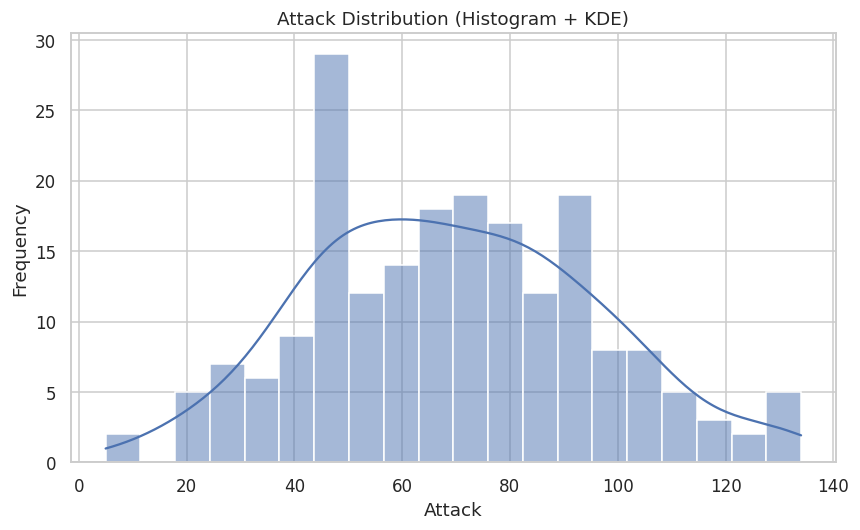

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="attack", kde=True, bins=20, color="#4C72B0")
plt.title("Attack Distribution (Histogram + KDE)")
plt.xlabel("Attack")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../visuals/attack_distribution.png", dpi=150)
plt.show()


In [7]:
print(df["attack"].describe())


count    200.00000
mean      69.38000
std       26.32834
min        5.00000
25%       50.00000
50%       65.00000
75%       86.25000
max      134.00000
Name: attack, dtype: float64


## Visualization 2: Correlation Heatmap

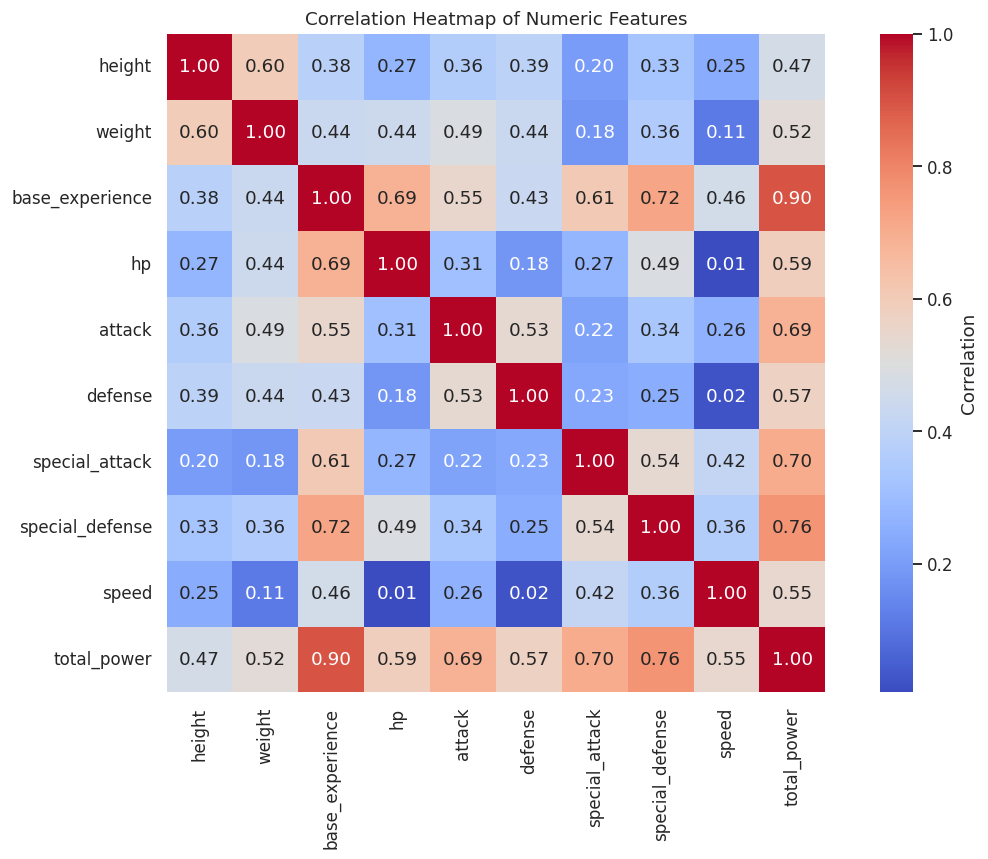

In [8]:
numeric_cols = ["height", "weight", "base_experience", "hp", "attack",
                "defense", "special_attack", "special_defense", "speed", "total_power"]

corr = df[numeric_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True,
            cbar_kws={"label": "Correlation"})
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.savefig("../visuals/correlation_heatmap.png", dpi=150)
plt.show()


In [9]:
corr_total_power = corr["total_power"].drop("total_power").sort_values(ascending=False)
print("Correlation of each feature with total_power:\n")
print(corr_total_power)


Correlation of each feature with total_power:

base_experience    0.896972
special_defense    0.763102
special_attack     0.701229
attack             0.688326
hp                 0.585285
defense            0.574361
speed              0.545450
weight             0.520399
height             0.465558
Name: total_power, dtype: float64


## Visualization 3: Pokémon Type Frequency Chart

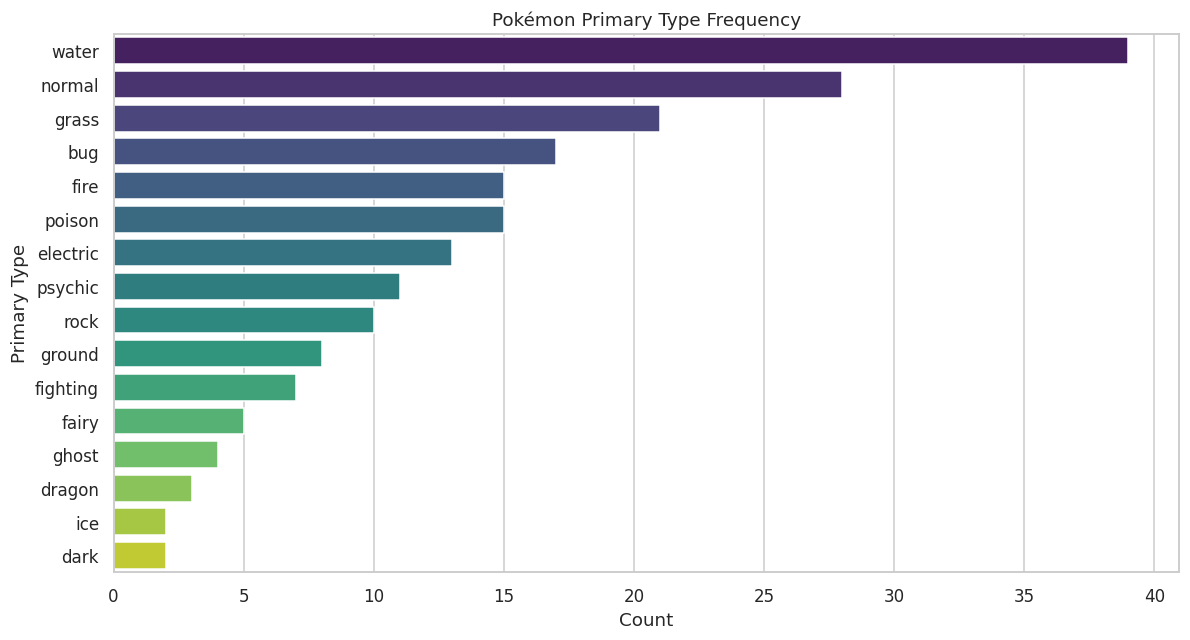

In [10]:
plt.figure(figsize=(11, 6))
type_counts = df["primary_type"].value_counts()
sns.barplot(x=type_counts.values, y=type_counts.index, hue=type_counts.index,
            palette="viridis", legend=False)
plt.title("Pok\u00e9mon Primary Type Frequency")
plt.xlabel("Count")
plt.ylabel("Primary Type")
plt.tight_layout()
plt.savefig("../visuals/type_frequency.png", dpi=150)
plt.show()


In [11]:
print(type_counts)


primary_type
water       39
normal      28
grass       21
bug         17
fire        15
poison      15
electric    13
psychic     11
rock        10
ground       8
fighting     7
fairy        5
ghost        4
dragon       3
ice          2
dark         2
Name: count, dtype: int64


## Visualization 4: Speed vs Attack Scatter Plot

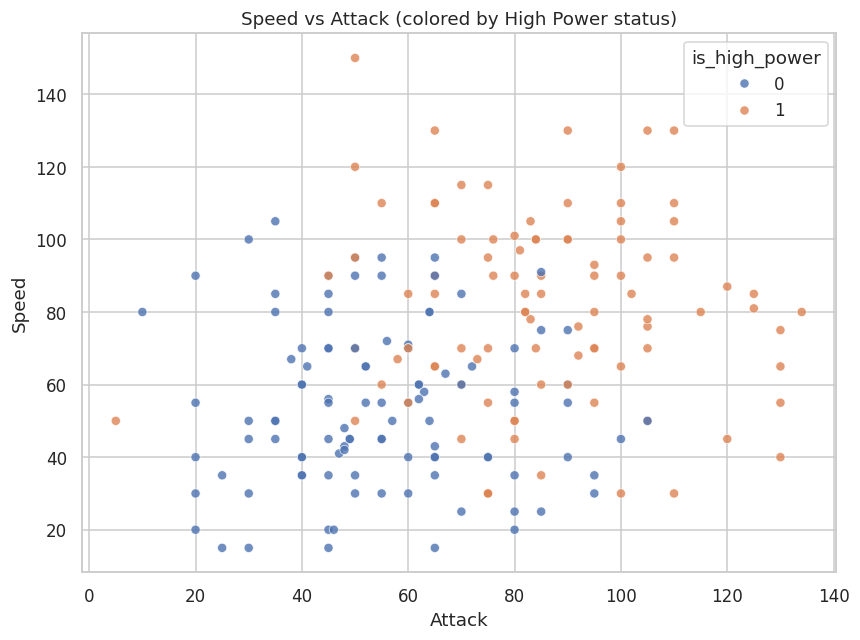

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="attack", y="speed", hue="is_high_power",
                 palette={0: "#4C72B0", 1: "#DD8452"}, alpha=0.8)
plt.title("Speed vs Attack (colored by High Power status)")
plt.xlabel("Attack")
plt.ylabel("Speed")
plt.legend(title="is_high_power")
plt.tight_layout()
plt.savefig("../visuals/speed_vs_attack.png", dpi=150)
plt.show()


## Outlier Detection (IQR Method on Attack)

In [13]:
q1, q3 = df["attack"].quantile([0.25, 0.75])
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outliers = df[(df["attack"] < lower_fence) | (df["attack"] > upper_fence)][["name", "attack"]]
print(f"IQR bounds for attack: [{lower_fence:.1f}, {upper_fence:.1f}]")
print(f"Outliers detected: {len(outliers)}")
print()
print("Highest-attack Pok\u00e9mon (context, even though none exceed the IQR fence):")
print(df.sort_values('attack', ascending=False)[['name', 'primary_type', 'attack']].head(8).to_string(index=False))


IQR bounds for attack: [-4.4, 140.6]
Outliers detected: 0

Highest-attack Pokémon (context, even though none exceed the IQR fence):
     name primary_type  attack
dragonite       dragon     134
  machamp     fighting     130
  kingler        water     130
  flareon         fire     130
   rhydon       ground     130
 gyarados        water     125
   pinsir          bug     125
hitmonlee     fighting     120


## Powerful Pokémon Categories & Type-Based Performance Trends

In [14]:
top_power = df.sort_values("total_power", ascending=False).head(10)[["name", "primary_type", "total_power"]]
print("Top 10 most powerful Pok\u00e9mon by total_power:\n")
print(top_power.to_string(index=False))


Top 10 most powerful Pokémon by total_power:

     name primary_type  total_power
   mewtwo      psychic          680
dragonite       dragon          600
      mew      psychic          600
 articuno          ice          580
   zapdos     electric          580
  moltres         fire          580
 arcanine         fire          555
 gyarados        water          540
  snorlax       normal          540
   crobat       poison          535


Average total_power by primary type:

primary_type
ice         517.5
dark        465.0
psychic     461.5
fire        447.7
dragon      440.0
rock        419.5
electric    413.1
ghost       412.5
fighting    412.1
water       406.5
grass       396.0
poison      394.3
ground      376.9
normal      368.5
bug         337.1
fairy       334.8
Name: total_power, dtype: float64


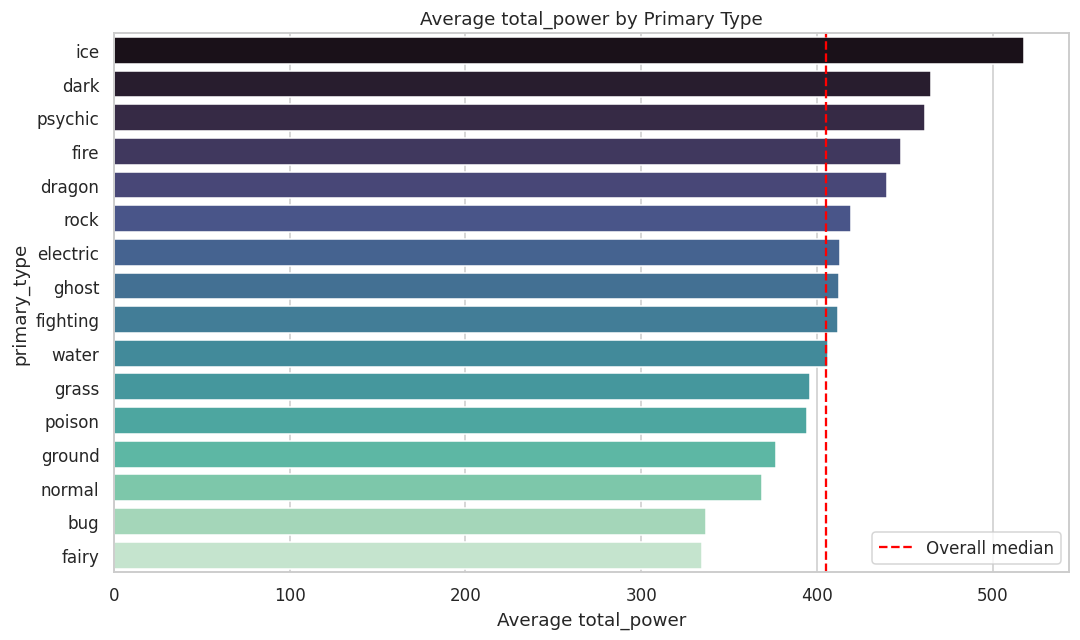

In [15]:
type_power = df.groupby("primary_type")["total_power"].mean().sort_values(ascending=False)
print("Average total_power by primary type:\n")
print(type_power.round(1))

plt.figure(figsize=(10, 6))
sns.barplot(x=type_power.values, y=type_power.index, hue=type_power.index,
            palette="mako", legend=False)
plt.axvline(df["total_power"].median(), color="red", linestyle="--", label="Overall median")
plt.title("Average total_power by Primary Type")
plt.xlabel("Average total_power")
plt.legend()
plt.tight_layout()
plt.show()


## Key Insights

**Strong correlations**
- `base_experience` has the strongest correlation with `total_power`
  (≈ 0.90) — Pokémon that yield more experience tend to be overall
  stronger, which makes intuitive sense since `base_experience` scales
  with a Pokémon's overall combat strength.
- `special_defense` (≈ 0.76) and `special_attack` (≈ 0.70) are the next
  strongest predictors of `total_power`.

**Weak correlations**
- `speed` shows almost no linear relationship with `hp` (≈ 0.01) or
  `defense` (≈ 0.02) — fast Pokémon are not reliably tankier or
  squishier, these stats vary independently.
- `weight` correlates weakly with `speed` (≈ 0.11), suggesting heavier
  Pokémon are not strongly penalized on speed in this dataset.

**Outliers**
- Using the IQR method, no Pokémon's `attack` stat falls outside the
  [Q1 − 1.5×IQR, Q3 + 1.5×IQR] fence — the distribution is right-skewed
  but without extreme statistical outliers. Dragonite (134), Machamp (130),
  Kingler (130), Flareon (130) and Rhydon (130) are the highest-attack
  Pokémon and sit at the natural top of a continuous distribution rather
  than as isolated extremes.

**Powerful Pokémon categories**
- Legendary/pseudo-legendary Pokémon dominate the top of `total_power`:
  Mewtwo (680), Dragonite (600), Mew (600), and the three legendary birds
  Articuno/Zapdos/Moltres (580 each).
- 95 of 200 Pokémon (47.5%) are classified `is_high_power = 1`, close to
  the expected ~50% split since the threshold is the dataset median.

**Type-based performance trends**
- Ice, Dark, and Psychic types have the highest average `total_power`
  (Ice ≈ 518, Dark ≈ 465, Psychic ≈ 461), driven by a small number of
  legendary representatives.
- Bug and Fairy types have the lowest average `total_power` (≈ 337 and
  ≈ 335 respectively), consistent with these types' early-game/support
  role in the Pokémon games.
